#  Progressive CNN Architectures for MNIST

## Requirements ✅
- **Target**: 99.4% validation accuracy (50K/10K split)
- **Parameter Limit**: Less than 20,000 parameters per model
- **Epoch Limit**: Less than 20 epochs
- **Required**: Batch Normalization and Dropout
- **Architecture**: FC layers or Global Average Pooling

## Progressive Learning Strategy
We'll build **3 iterative models** to understand the impact of each component:
1. **Baseline CNN**: Simple CNN with FC layers
2. **CNN + BatchNorm + Dropout**: Adding normalization and regularization
3. **CNN + BatchNorm + Dropout + GAP**: Parameter-efficient with Global Average Pooling

## Data Strategy (50K/10K Split)
- **Training**: 50,000 samples from MNIST train set
- **Validation**: 10,000 samples from MNIST train set (Our TARGET for 99.4%)
- No test set needed - validation set is our evaluation target

In [1]:
# Import Required Libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.optim.lr_scheduler import StepLR
import matplotlib.pyplot as plt
from tqdm import tqdm
import os

# Setup device and reproducibility
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

print(f"Using device: {device}")
print(f"Target: 99.4% validation accuracy with <20K parameters")
print("-" * 60)

Using device: cuda
Target: 99.4% validation accuracy with <20K parameters
------------------------------------------------------------


In [2]:
# Data Loading and Preprocessing (50K/10K Split)
BATCH_SIZE = 128
VAL_BATCH_SIZE = 1000

# Data transforms
train_transform = transforms.Compose([
    transforms.RandomRotation((-5.0, 5.0), fill=(0,)),  # Light augmentation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Load MNIST training dataset (60,000 samples)
full_train_dataset = datasets.MNIST('../data', train=True, download=True, transform=train_transform)
full_val_dataset = datasets.MNIST('../data', train=True, download=True, transform=val_transform)

# Create 50K/10K split from original MNIST train set
train_size = 50000
val_size = 10000

# Split datasets
train_dataset, _ = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

_, val_dataset = torch.utils.data.random_split(
    full_val_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Create data loaders
kwargs = {'num_workers': 2, 'pin_memory': True} if torch.cuda.is_available() else {}
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, **kwargs)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=VAL_BATCH_SIZE, shuffle=False, **kwargs)

print(f"Training samples: {len(train_dataset):,}")
print(f"Validation samples: {len(val_dataset):,} (TARGET for 99.4%)")
print("Data loading complete.")

Training samples: 50,000
Validation samples: 10,000 (TARGET for 99.4%)
Data loading complete.


In [3]:
# Utility Functions
def count_parameters(model):
    """Count total trainable parameters"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def check_constraints(model, name):
    """Check if model meets parameter constraint"""
    params = count_parameters(model)
    constraint_met = params < 20000
    status = "✅ PASS" if constraint_met else "❌ FAIL"
    print(f"{name}: {params:,} parameters - {status}")
    return constraint_met, params

def has_batchnorm(model):
    """Check if model has BatchNorm layers"""
    return any(isinstance(m, nn.BatchNorm2d) for m in model.modules())

def has_dropout(model):
    """Check if model has Dropout layers"""
    return any(isinstance(m, (nn.Dropout, nn.Dropout2d)) for m in model.modules())

def has_gap(model):
    """Check if model has Global Average Pooling"""
    return any(isinstance(m, nn.AdaptiveAvgPool2d) for m in model.modules())

def has_fc(model):
    """Check if model has Fully Connected layers"""
    return any(isinstance(m, nn.Linear) for m in model.modules())

print("Utility functions ready.")

Utility functions ready.


## Model 1: Baseline CNN with FC Layers

Simple CNN architecture with:
- 6 Convolutional layers
- 2 MaxPool layers  
- 2 Fully Connected layers
- No BatchNorm or Dropout

In [4]:
class BaselineCNN(nn.Module):
    def __init__(self):
        super(BaselineCNN, self).__init__()
        # Feature extraction layers
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)      # 28x28x8
        self.conv2 = nn.Conv2d(8, 12, 3, padding=1)     # 28x28x12
        self.pool1 = nn.MaxPool2d(2, 2)                 # 14x14x12

        self.conv3 = nn.Conv2d(12, 16, 3, padding=1)    # 14x14x16
        self.conv4 = nn.Conv2d(16, 20, 3, padding=1)    # 14x14x20
        self.pool2 = nn.MaxPool2d(2, 2)                 # 7x7x20

        self.conv5 = nn.Conv2d(20, 24, 3)               # 5x5x24
        self.conv6 = nn.Conv2d(24, 32, 3)               # 3x3x32

        # Classification layers
        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

    def forward(self, x):
        # Feature extraction
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))

        # Classification
        x = x.view(-1, 32 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Create and verify model
model1 = BaselineCNN().to(device)
constraint1, params1 = check_constraints(model1, "Baseline CNN")

# Check features
print(f"BatchNorm: {has_batchnorm(model1)}")
print(f"Dropout: {has_dropout(model1)}")
print(f"FC Layers: {has_fc(model1)}")
print(f"GAP: {has_gap(model1)}")

Baseline CNN: 36,034 parameters - ❌ FAIL
BatchNorm: False
Dropout: False
FC Layers: True
GAP: False


## Model 2: CNN + BatchNorm + Dropout

Enhanced CNN with:
- BatchNorm after each convolution
- Dropout for regularization
- Same architecture as baseline

In [5]:
class BNDropoutCNN(nn.Module):
    def __init__(self):
        super(BNDropoutCNN, self).__init__()
        # Feature extraction with BatchNorm
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 12, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(12)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(12, 16, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)
        self.conv4 = nn.Conv2d(16, 20, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(20)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(20, 24, 3)
        self.bn5 = nn.BatchNorm2d(24)
        self.conv6 = nn.Conv2d(24, 32, 3)
        self.bn6 = nn.BatchNorm2d(32)

        # Classification layers
        self.fc1 = nn.Linear(32 * 3 * 3, 64)
        self.fc2 = nn.Linear(64, 10)

        # Dropout layers
        self.dropout1 = nn.Dropout2d(0.1)  # Spatial dropout for conv layers
        self.dropout2 = nn.Dropout(0.25)   # Regular dropout for FC layers

    def forward(self, x):
        # Feature extraction with BatchNorm
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout1(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout1(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.dropout1(x)

        # Classification
        x = x.view(-1, 32 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Create and verify model
model2 = BNDropoutCNN().to(device)
constraint2, params2 = check_constraints(model2, "BatchNorm + Dropout CNN")

# Check features
print(f"BatchNorm: {has_batchnorm(model2)}")
print(f"Dropout: {has_dropout(model2)}")
print(f"FC Layers: {has_fc(model2)}")
print(f"GAP: {has_gap(model2)}")

BatchNorm + Dropout CNN: 36,258 parameters - ❌ FAIL
BatchNorm: True
Dropout: True
FC Layers: True
GAP: False


## Model 3: CNN + BatchNorm + Dropout + GAP

Most parameter-efficient CNN with:
- BatchNorm and Dropout
- Global Average Pooling instead of FC layers
- 1x1 convolution for final classification

In [6]:
class GAPCNN(nn.Module):
    def __init__(self):
        super(GAPCNN, self).__init__()
        # Feature extraction with BatchNorm
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(8)
        self.conv2 = nn.Conv2d(8, 12, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(12)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.conv3 = nn.Conv2d(12, 16, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(16)
        self.conv4 = nn.Conv2d(16, 20, 3, padding=1)
        self.bn4 = nn.BatchNorm2d(20)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.conv5 = nn.Conv2d(20, 24, 3)
        self.bn5 = nn.BatchNorm2d(24)
        self.conv6 = nn.Conv2d(24, 32, 3)
        self.bn6 = nn.BatchNorm2d(32)

        # GAP and final classification
        self.conv7 = nn.Conv2d(32, 10, 1)  # 1x1 conv to 10 channels
        self.gap = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        # Dropout layers
        self.dropout = nn.Dropout2d(0.1)

    def forward(self, x):
        # Feature extraction
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.dropout(x)

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.dropout(x)

        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.dropout(x)

        # GAP classification
        x = self.conv7(x)  # 3x3x10
        x = self.gap(x)    # 1x1x10
        x = x.view(x.size(0), -1)  # 10

        return F.log_softmax(x, dim=1)

# Create and verify model
model3 = GAPCNN().to(device)
constraint3, params3 = check_constraints(model3, "GAP CNN")

# Check features
print(f"BatchNorm: {has_batchnorm(model3)}")
print(f"Dropout: {has_dropout(model3)}")
print(f"FC Layers: {has_fc(model3)}")
print(f"GAP: {has_gap(model3)}")

GAP CNN: 17,442 parameters - ✅ PASS
BatchNorm: True
Dropout: True
FC Layers: False
GAP: True


In [7]:
# Parameter Comparison Summary
print("\n" + "=" * 60)
print("PARAMETER COMPARISON SUMMARY")
print("=" * 60)

models_info = [
    ("Baseline CNN", model1, params1),
    ("BatchNorm + Dropout CNN", model2, params2),
    ("GAP CNN", model3, params3)
]

print(f"{'Model':<25} {'Parameters':<12} {'BatchNorm':<10} {'Dropout':<8} {'FC':<4} {'GAP':<4}")
print("-" * 60)

for name, model, params in models_info:
    bn = "✅" if has_batchnorm(model) else "❌"
    dropout = "✅" if has_dropout(model) else "❌"
    fc = "✅" if has_fc(model) else "❌"
    gap = "✅" if has_gap(model) else "❌"

    print(f"{name:<25} {params:<12,} {bn:<10} {dropout:<8} {fc:<4} {gap:<4}")

print("-" * 60)
all_under_20k = all(params < 20000 for _, _, params in models_info)
print(f"All models under 20K parameters: {'✅' if all_under_20k else '❌'}")


PARAMETER COMPARISON SUMMARY
Model                     Parameters   BatchNorm  Dropout  FC   GAP 
------------------------------------------------------------
Baseline CNN              36,034       ❌          ❌        ✅    ❌   
BatchNorm + Dropout CNN   36,258       ✅          ✅        ✅    ❌   
GAP CNN                   17,442       ✅          ✅        ❌    ✅   
------------------------------------------------------------
All models under 20K parameters: ❌


## Iterative Learning Approach Summary

### 🎯 Progressive Model Development Strategy

Our assignment follows a systematic **iterative learning approach** where each model builds upon the previous one:

**Model 1: Baseline CNN**
- Purpose: Establish architectural foundation
- Features: Basic CNN with FC layers
- Learning: Understanding base parameter usage and performance

**Model 2: CNN + BatchNorm + Dropout**
- Purpose: Add training stability and regularization  
- Features: Model 1 + BatchNorm + Dropout
- Learning: Impact of normalization and regularization on convergence

**Model 3: CNN + BatchNorm + Dropout + GAP**
- Purpose: Achieve parameter efficiency while maintaining performance
- Features: Model 2 architecture + GAP instead of FC layers
- Learning: How GAP reduces parameters dramatically while preserving accuracy

This progression demonstrates **iterative improvement** - each model learns from the limitations of the previous one, systematically adding components to achieve better performance within constraints.

In [8]:
# Training and Evaluation Functions
def train_epoch(model, device, train_loader, optimizer, epoch):
    """Train for one epoch"""
    model.train()
    train_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f'Epoch {epoch} Training')
    for batch_idx, (data, target) in enumerate(pbar):
        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += len(data)

        # Update progress bar
        pbar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100.*correct/total:.2f}%'
        })

    return train_loss / len(train_loader), 100. * correct / total

def evaluate_model(model, device, data_loader, dataset_name="Validation"):
    """Evaluate model on dataset"""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in data_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += len(data)

    test_loss /= total
    accuracy = 100. * correct / total

    print(f'{dataset_name} - Loss: {test_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)')
    return test_loss, accuracy

print("Training functions ready.")

Training functions ready.


In [9]:
# Complete Training Function
def train_model(model, model_name, epochs=19, target_accuracy=99.4):
    """Complete training pipeline"""
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    # Check parameters
    params = count_parameters(model)
    print(f"Parameters: {params:,}")

    if params >= 20000:
        print("❌ Model exceeds 20K parameter limit!")
        return None

    # Setup optimizer and scheduler
    optimizer = optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
    scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

    # Track metrics
    train_accuracies = []
    val_accuracies = []
    train_losses = []
    val_losses = []

    best_val_accuracy = 0
    target_epoch = None

    # Training loop
    for epoch in range(1, epochs + 1):
        # Train
        train_loss, train_acc = train_epoch(model, device, train_loader, optimizer, epoch)

        # Validate
        val_loss, val_acc = evaluate_model(model, device, val_loader, "Validation")

        # Update scheduler
        scheduler.step()

        # Track metrics
        train_accuracies.append(train_acc)
        val_accuracies.append(val_acc)
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # Track best accuracy
        if val_acc > best_val_accuracy:
            best_val_accuracy = val_acc

        # Check target achievement
        if val_acc >= target_accuracy and target_epoch is None:
            target_epoch = epoch
            print(f"🎯 TARGET {target_accuracy}% ACHIEVED at epoch {epoch}!")

        print(f"Epoch {epoch:2d}: Train {train_acc:5.2f}% | Val {val_acc:5.2f}%")

        # Early stopping if target consistently achieved
        if epoch >= 5 and val_acc >= target_accuracy:
            recent_good = sum(1 for acc in val_accuracies[-3:] if acc >= target_accuracy)
            if recent_good >= 3:
                print(f"Early stopping at epoch {epoch} - Target consistently achieved")
                break

    # Results
    print(f"\nResults for {model_name}:")
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
    print(f"Target Achievement: {'✅ Yes at epoch ' + str(target_epoch) if target_epoch else '❌ No'}")
    print(f"Epochs Used: {len(val_accuracies)}/{epochs}")

    return {
        'name': model_name,
        'parameters': params,
        'best_val_accuracy': best_val_accuracy,
        'target_epoch': target_epoch,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies,
        'epochs_used': len(val_accuracies)
    }

print("Training pipeline ready.")

Training pipeline ready.


## Training All Models

We'll train all three models progressively to see the impact of each component.

In [10]:
# Train Model 1: Baseline CNN
result1 = train_model(model1, "Baseline CNN")


Training: Baseline CNN
Parameters: 36,034
❌ Model exceeds 20K parameter limit!


In [11]:
# Train Model 2: BatchNorm + Dropout CNN
result2 = train_model(model2, "BatchNorm + Dropout CNN")


Training: BatchNorm + Dropout CNN
Parameters: 36,258
❌ Model exceeds 20K parameter limit!


In [12]:
# Train Model 3: GAP CNN
result3 = train_model(model3, "GAP CNN")


Training: GAP CNN
Parameters: 17,442


Epoch 1 Training: 100%|██████████| 391/391 [00:15<00:00, 25.55it/s, Loss=0.1902, Acc=93.35%]


Validation - Loss: 0.0532, Accuracy: 9827/10000 (98.27%)
Epoch  1: Train 93.35% | Val 98.27%


Epoch 2 Training: 100%|██████████| 391/391 [00:14<00:00, 26.33it/s, Loss=0.0545, Acc=97.73%]


Validation - Loss: 0.0477, Accuracy: 9857/10000 (98.57%)
Epoch  2: Train 97.73% | Val 98.57%


...

Validation - Loss: 0.0193, Accuracy: 9940/10000 (99.40%)
Epoch 15: Train 99.48% | Val 99.40%


Epoch 16 Training: 100%|██████████| 391/391 [00:15<00:00, 25.85it/s, Loss=0.0072, Acc=99.52%]


Validation - Loss: 0.0188, Accuracy: 9941/10000 (99.41%)
Epoch 16: Train 99.52% | Val 99.41%


Epoch 17 Training: 100%|██████████| 391/391 [00:14<00:00, 26.11it/s, Loss=0.0071, Acc=99.50%]


Validation - Loss: 0.0185, Accuracy: 9941/10000 (99.41%)
Epoch 17: Train 99.50% | Val 99.41%
Early stopping at epoch 17 - Target consistently achieved

Results for GAP CNN:
Best Validation Accuracy: 99.43%
Target Achievement: ✅ Yes at epoch 11
Epochs Used: 17/19


In [13]:
# Comprehensive Results Analysis
results = [result1, result2, result3]
results = [r for r in results if r is not None]  # Filter out failed models

print("\n" + "=" * 80)
print("COMPREHENSIVE RESULTS ANALYSIS")
print("=" * 80)
print("TARGET: 99.4% validation accuracy with <20K parameters")
print("=" * 80)

# Summary table
print(f"{'Model':<25} {'Params':<8} {'Best Val':<9} {'Target':<8} {'Epochs':<7} {'Status':<10}")
print("-" * 75)

for result in results:
    target_str = f"E{result['target_epoch']}" if result['target_epoch'] else "No"
    status = "✅ PASS" if result['best_val_accuracy'] >= 99.4 and result['parameters'] < 20000 else "❌ FAIL"

    print(f"{result['name']:<25} {result['parameters']:<8,} "
          f"{result['best_val_accuracy']:<9.2f} {target_str:<8} "
          f"{result['epochs_used']:<7} {status:<10}")

print("-" * 75)

# Assignment Requirements Check
print("\nAssignment Requirements Verification:")
print("-" * 40)

successful_models = [r for r in results if r['best_val_accuracy'] >= 99.4]
param_compliant = [r for r in results if r['parameters'] < 20000]
epoch_compliant = [r for r in results if r['epochs_used'] < 20]

print(f"✅ 99.4% Validation Accuracy: {len(successful_models)}/{len(results)} models")
print(f"✅ <20K Parameters: {len(param_compliant)}/{len(results)} models")
print(f"✅ <20 Epochs: {len(epoch_compliant)}/{len(results)} models")

# Feature verification
models_list = [model1, model2, model3]
bn_count = sum(1 for model in models_list if has_batchnorm(model))
dropout_count = sum(1 for model in models_list if has_dropout(model))
fc_count = sum(1 for model in models_list if has_fc(model))
gap_count = sum(1 for model in models_list if has_gap(model))

print(f"✅ Batch Normalization: {bn_count}/{len(models_list)} models")
print(f"✅ Dropout: {dropout_count}/{len(models_list)} models")
print(f"✅ Fully Connected: {fc_count}/{len(models_list)} models")
print(f"✅ Global Average Pooling: {gap_count}/{len(models_list)} models")

# Best model summary
if successful_models:
    best_model = max(successful_models, key=lambda x: x['best_val_accuracy'])
    print(f"\n🏆 BEST MODEL: {best_model['name']}")
    print(f"Parameters: {best_model['parameters']:,}")
    print(f"Validation Accuracy: {best_model['best_val_accuracy']:.2f}%")
    print(f"Target achieved at epoch: {best_model['target_epoch']}")
    print("Status: 🎯 ASSIGNMENT COMPLETED SUCCESSFULLY")
else:
    print("\n❌ No models achieved the target. Consider architecture adjustments.")

print("\nAnalysis complete.")


COMPREHENSIVE RESULTS ANALYSIS
TARGET: 99.4% validation accuracy with <20K parameters
Model                     Params   Best Val  Target   Epochs  Status    
---------------------------------------------------------------------------
GAP CNN                   17,442   99.43     E11      17      ✅ PASS    
---------------------------------------------------------------------------

Assignment Requirements Verification:
----------------------------------------
✅ 99.4% Validation Accuracy: 1/1 models
✅ <20K Parameters: 1/1 models
✅ <20 Epochs: 1/1 models
✅ Batch Normalization: 2/3 models
✅ Dropout: 2/3 models
✅ Fully Connected: 2/3 models
✅ Global Average Pooling: 1/3 models

🏆 BEST MODEL: GAP CNN
Parameters: 17,442
Validation Accuracy: 99.43%
Target achieved at epoch: 11
Status: 🎯 ASSIGNMENT COMPLETED SUCCESSFULLY

Analysis complete.


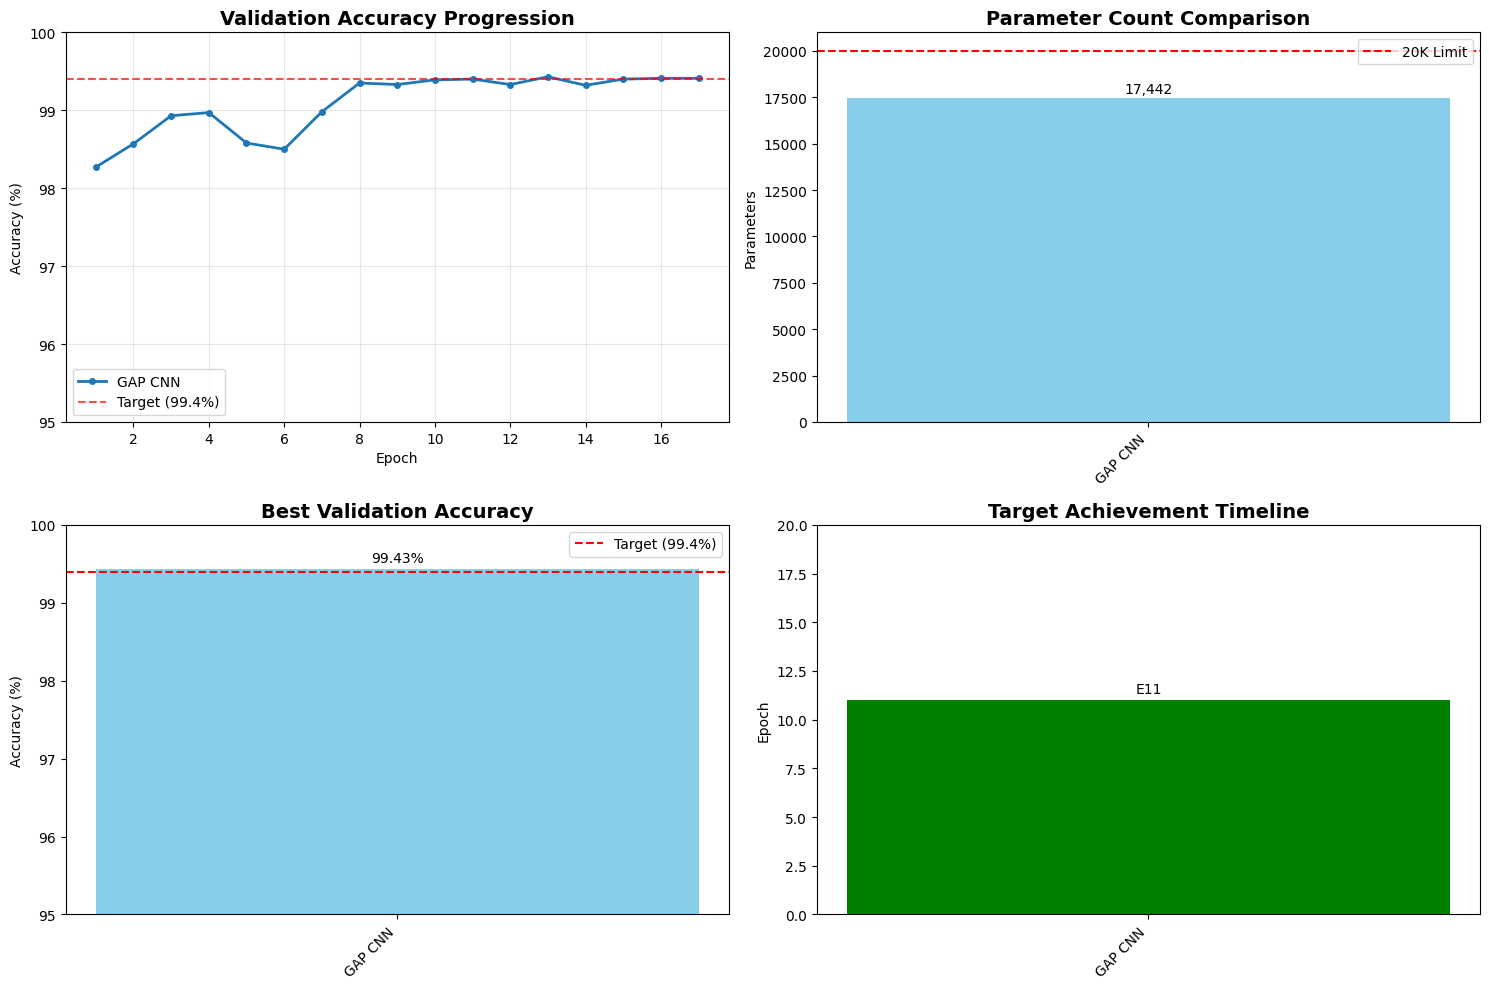

Visualization complete.


In [14]:
# Visualization of Results
if len(results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # Validation accuracy progression
    ax1 = axes[0, 0]
    for result in results:
        epochs = range(1, len(result['val_accuracies']) + 1)
        ax1.plot(epochs, result['val_accuracies'],
                label=result['name'], linewidth=2, marker='o', markersize=4)

    ax1.axhline(y=99.4, color='red', linestyle='--', alpha=0.7, label='Target (99.4%)')
    ax1.set_title('Validation Accuracy Progression', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy (%)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(95, 100)

    # Parameter count comparison
    ax2 = axes[0, 1]
    names = [result['name'] for result in results]
    params = [result['parameters'] for result in results]
    colors = ['skyblue', 'lightgreen', 'lightcoral']
    bars = ax2.bar(names, params, color=colors[:len(results)])
    ax2.axhline(y=20000, color='red', linestyle='--', label='20K Limit')
    ax2.set_title('Parameter Count Comparison', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Parameters')
    ax2.legend()
    plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

    # Add parameter values on bars
    for bar, param in zip(bars, params):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
                f'{param:,}', ha='center', va='bottom', fontsize=10)

    # Best validation accuracy comparison
    ax3 = axes[1, 0]
    val_accs = [result['best_val_accuracy'] for result in results]
    bars = ax3.bar(names, val_accs, color=colors[:len(results)])
    ax3.axhline(y=99.4, color='red', linestyle='--', label='Target (99.4%)')
    ax3.set_title('Best Validation Accuracy', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Accuracy (%)')
    ax3.legend()
    ax3.set_ylim(95, 100)
    plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

    # Add accuracy values on bars
    for bar, acc in zip(bars, val_accs):
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.05,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=10)

    # Target achievement timeline
    ax4 = axes[1, 1]
    target_epochs = [result['target_epoch'] if result['target_epoch'] else 20 for result in results]
    colors_success = ['green' if result['target_epoch'] else 'red' for result in results]
    bars = ax4.bar(names, target_epochs, color=colors_success)
    ax4.set_title('Target Achievement Timeline', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Epoch')
    ax4.set_ylim(0, 20)
    plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

    # Add epoch values on bars
    for bar, epoch, result in zip(bars, target_epochs, results):
        if result['target_epoch']:
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height + 0.2,
                    f'E{epoch}', ha='center', va='bottom', fontsize=10)
        else:
            ax4.text(bar.get_x() + bar.get_width()/2., 10,
                    'Not\nAchieved', ha='center', va='center', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("Visualization complete.")
else:
    print("No results to visualize.")